In [1]:
import os
import warnings

# 1. Suppress the TensorFlow C++ "already registered" spam
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')

# 2. Memory defragmentation for 15GB GPUs
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure clean GPU state
torch.cuda.empty_cache()
print(f"PyTorch Version: {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0+cu128 | GPU: Tesla T4


# Task 5.1 - Data Augmentation & Barlow Twins Architecture

In [2]:
class TwoViewTransform:
    """Generates two augmented views of an AQI image (gentle color jitter to preserve haze)."""
    def __init__(self):
        self.transform = T.Compose([
            T.RandomResizedCrop(224, scale=(0.6, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([T.ColorJitter(0.2, 0.2, 0.2, 0.1)], p=0.4),
            T.RandomGrayscale(p=0.1),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    def __call__(self, x):
        return [self.transform(x), self.transform(x)]

class BarlowTwins(nn.Module):
    def __init__(self, backbone_name='resnet50', proj_hidden_dim=2048, proj_out_dim=2048, lambd=0.0051):
        super().__init__()
        self.lambd = lambd
        
        # 1. Backbone (e.g., ResNet-50 without classification head)
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        feature_dim = self.backbone.num_features
        
        # 2. Projector (maps to representation space for SSL loss)
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, proj_hidden_dim),
            nn.BatchNorm1d(proj_hidden_dim),
            nn.ReLU(),
            nn.Linear(proj_hidden_dim, proj_hidden_dim),
            nn.BatchNorm1d(proj_hidden_dim),
            nn.ReLU(),
            nn.Linear(proj_hidden_dim, proj_out_dim)
        )
        # Normalization layer for the cross-correlation matrix
        self.bn = nn.BatchNorm1d(proj_out_dim, affine=False)

    def off_diagonal(self, x):
        n, m = x.shape
        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

    def forward(self, y1, y2):
        # Extract features and project
        z1 = self.projector(self.backbone(y1))
        z2 = self.projector(self.backbone(y2))

        # Empirical cross-correlation matrix
        c = self.bn(z1).T @ self.bn(z2)
        c.div_(z1.shape[0])

        # Loss function
        on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
        off_diag = self.off_diagonal(c).pow_(2).sum()
        loss = on_diag + self.lambd * off_diag
        return loss

# Task 5.1 - Memory-Safe Pretraining Loop

In [3]:
import os
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# --- 1. FIND ALL IMAGES ---
root_directory = '/kaggle/input/' 
image_paths = list(Path(root_directory).rglob('*.jpg'))
print(f"📸 Found {len(image_paths)} image files.")

# --- 2. DEFINE THE CUSTOM DATASET ---
class PM25VisionPathsDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        img_path = str(self.file_paths[idx])
        # Convert to RGB to ensure exactly 3 channels (drops alpha if present)
        image = Image.open(img_path).convert('RGB')
        
        # Apply the TwoViewTransform (from Cell 2)
        if self.transform:
            image = self.transform(image)
            
        return image, 0 

print("Setting up the Dataset and DataLoader...")

# --- 3. INSTANTIATE DATASET AND DATALOADER ---
ssl_train_dataset = PM25VisionPathsDataset(
    file_paths=image_paths, 
    transform=TwoViewTransform()
)

dataloader = DataLoader(
    ssl_train_dataset, 
    batch_size=16,          # Small batch size to avoid the 15GB memory error
    shuffle=True,           # Crucial for SSL
    num_workers=2,          
    drop_last=True          # Prevents tensor size errors on the last batch
)

print(f"✅ DataLoader ready! Total batches per epoch: {len(dataloader)}")

# --- 4. INITIALIZE MODEL & PRETRAINING LOOP ---
print("Initializing Barlow Twins model...")
model = BarlowTwins('resnet50').cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler() # For Mixed Precision memory saving

epochs = 30
accum_steps = 4 # Effective Batch Size = 16 * 4 = 64

model.train()
print("Starting Pretraining...")
for epoch in range(epochs):
    epoch_loss = 0.0
    optimizer.zero_grad()
    
    for i, (images, _) in enumerate(dataloader):
        x1, x2 = images[0].cuda(), images[1].cuda()
        
        with torch.cuda.amp.autocast():
            loss = model(x1, x2) / accum_steps
            
        scaler.scale(loss).backward()
        
        if (i + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
        epoch_loss += loss.item() * accum_steps
        
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss/len(dataloader):.4f}")

# Save the Frozen Backbone!
torch.save(model.backbone.state_dict(), "barlow_twins_encoder.pth")
print("Pretraining complete. Backbone saved as 'barlow_twins_encoder.pth'")

📸 Found 11474 image files.
Setting up the Dataset and DataLoader...
✅ DataLoader ready! Total batches per epoch: 717
Initializing Barlow Twins model...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Starting Pretraining...
Epoch [1/30] Loss: 2037.4172
Epoch [2/30] Loss: 1697.4687
Epoch [3/30] Loss: 1608.8390
Epoch [4/30] Loss: 1570.7594
Epoch [5/30] Loss: 1546.2607
Epoch [6/30] Loss: 1530.2500
Epoch [7/30] Loss: 1519.4885
Epoch [8/30] Loss: 1511.1581
Epoch [9/30] Loss: 1504.3396
Epoch [10/30] Loss: 1499.1718
Epoch [11/30] Loss: 1495.3007
Epoch [12/30] Loss: 1490.8908
Epoch [13/30] Loss: 1487.0562
Epoch [14/30] Loss: 1483.7234
Epoch [15/30] Loss: 1481.9063
Epoch [16/30] Loss: 1478.0322
Epoch [17/30] Loss: 1475.8156
Epoch [18/30] Loss: 1474.9311
Epoch [19/30] Loss: 1472.2716
Epoch [20/30] Loss: 1470.1239
Epoch [21/30] Loss: 1467.3323
Epoch [22/30] Loss: 1467.5118
Epoch [23/30] Loss: 1465.2400
Epoch [24/30] Loss: 1464.8370
Epoch [25/30] Loss: 1461.5456
Epoch [26/30] Loss: 1461.6041
Epoch [27/30] Loss: 1459.4126
Epoch [28/30] Loss: 1458.8372
Epoch [29/30] Loss: 1457.1997
Epoch [30/30] Loss: 1457.7602
Pretraining complete. Backbone saved as 'barlow_twins_encoder.pth'


# The Feature Extraction Step

In [4]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import numpy as np

# 1. Standard Transform for Evaluation (NO heavy augmentation, just resize and normalize)
eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dir = '/kaggle/input/datasets/deadcardassian/pm25vision/train'
test_dir = '/kaggle/input/datasets/deadcardassian/pm25vision/test'   

try:
    train_eval_dataset = torchvision.datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=eval_transform)
    
    train_loader_eval = DataLoader(train_eval_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    print(f"Loaded {len(train_eval_dataset)} train and {len(test_dataset)} test evaluation images.")
except Exception as e:
    print(f"Dataset loading error: {e}")
    print("If your dataset uses a CSV file for labels instead of folders, you must load it here!")

# 3. Feature Extraction Function
def extract_features(loader, model):
    model.eval()
    all_features, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            x = images.cuda()
            with torch.cuda.amp.autocast():
                embeddings = model.backbone(x) 
            all_features.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
            
    return np.vstack(all_features), np.concatenate(all_labels)

print("Extracting features... (This takes a moment)")
X_train_feat, y_train = extract_features(train_loader_eval, model)
X_test_feat, y_test = extract_features(test_loader, model)

print(f"Extraction Complete!")
print(f"Train Features Shape: {X_train_feat.shape}") 
print(f"Test Features Shape: {X_test_feat.shape}")

Loaded 8374 train and 3100 test evaluation images.
Extracting features... (This takes a moment)
Extraction Complete!
Train Features Shape: (8374, 2048)
Test Features Shape: (3100, 2048)


# Task 5.3 - Embedding Analysis

E0000 00:00:1776360531.114860      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776360531.235316      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776360532.339085      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776360532.339115      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776360532.339118      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776360532.339121      24 computation_placer.cc:177] computation placer already registered. Please check linka

Silhouette Score (Test Split): -0.0015


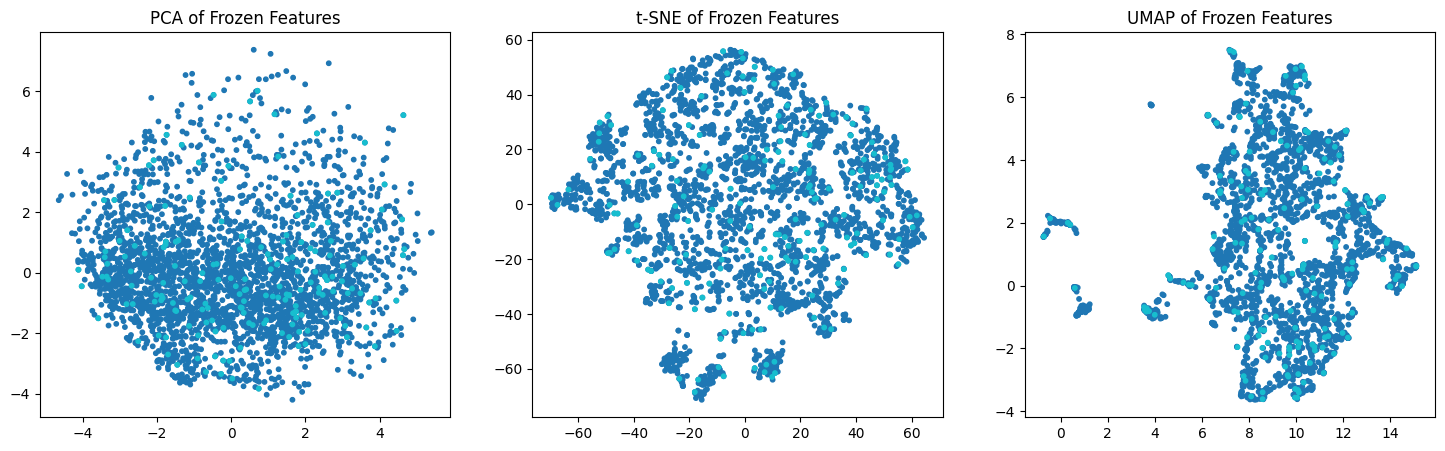

In [5]:
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Silhouette Score
sil_score = silhouette_score(X_test_feat, y_test)
print(f"Silhouette Score (Test Split): {sil_score:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. PCA
pca = PCA(n_components=2).fit_transform(X_test_feat)
axes[0].scatter(pca[:, 0], pca[:, 1], c=y_test, cmap='tab10', s=10)
axes[0].set_title("PCA of Frozen Features")

# 3. t-SNE
tsne = TSNE(n_components=2, perplexity=30).fit_transform(X_test_feat)
axes[1].scatter(tsne[:, 0], tsne[:, 1], c=y_test, cmap='tab10', s=10)
axes[1].set_title("t-SNE of Frozen Features")

# 4. UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(X_test_feat)
axes[2].scatter(embedding[:, 0], embedding[:, 1], c=y_test, cmap='tab10', s=10)
axes[2].set_title("UMAP of Frozen Features")

plt.show()

# Task 5.2 - Downstream Evaluation (Shallow Heads)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

classifiers = {
    "Linear Probe (Logistic)": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel='linear'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "MLP Head": MLPClassifier(hidden_layer_sizes=(512,), max_iter=500)
}

print("--- Downstream Evaluation on Frozen Features ---")
for name, clf in classifiers.items():
    clf.fit(X_train_feat, y_train)
    acc = clf.score(X_test_feat, y_test)
    print(f"{name:25s} | Accuracy: {acc:.4f}")

# Optional: Print full report for the Linear Probe (Primary Yardstick)
best_model = classifiers["Linear Probe (Logistic)"]
y_pred = best_model.predict(X_test_feat)
print("\nLinear Probe Detailed Report:")
print(classification_report(y_test, y_pred))

--- Downstream Evaluation on Frozen Features ---
Linear Probe (Logistic)   | Accuracy: 0.9403
SVM (Linear)              | Accuracy: 0.9419
Decision Tree             | Accuracy: 0.9377
Random Forest             | Accuracy: 0.9419
MLP Head                  | Accuracy: 0.9410

Linear Probe Detailed Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2920
           1       0.00      0.00      0.00       180

    accuracy                           0.94      3100
   macro avg       0.47      0.50      0.48      3100
weighted avg       0.89      0.94      0.91      3100



# Task 5.4 - Metrics & Label Efficiency Curves

--- k-NN Evaluation ---
k= 1 | Accuracy: 0.9313
k= 5 | Accuracy: 0.9419
k=20 | Accuracy: 0.9419


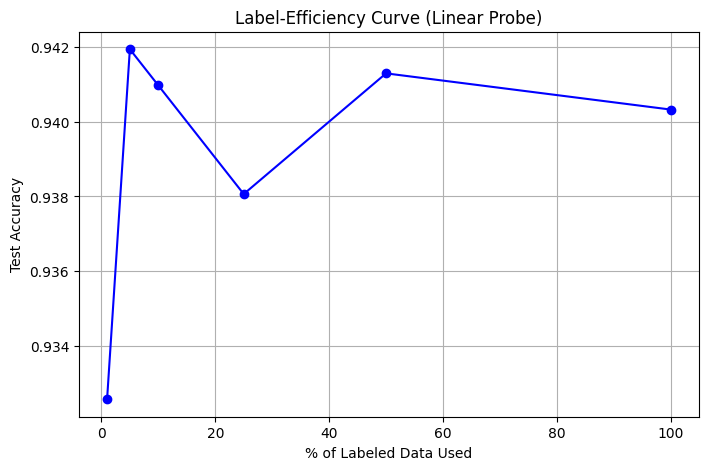

--- Architecture Profile ---
GFLOPs: 4.13
Parameters: 23.51 M


In [7]:
!pip install thop
from sklearn.neighbors import KNeighborsClassifier
from thop import profile 

# --- 1. k-NN Accuracy ---
print("--- k-NN Evaluation ---")
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_feat, y_train)
    print(f"k={k:2d} | Accuracy: {knn.score(X_test_feat, y_test):.4f}")

# --- 2. Label Efficiency Curves ---
fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]
efficiency_results = []

for frac in fractions:
    subset_size = int(len(X_train_feat) * frac)
    indices = np.random.choice(len(X_train_feat), subset_size, replace=False)
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_feat[indices], y_train[indices])
    efficiency_results.append(clf.score(X_test_feat, y_test))

plt.figure(figsize=(8, 5))
plt.plot([f * 100 for f in fractions], efficiency_results, marker='o', linestyle='-', color='b')
plt.title("Label-Efficiency Curve (Linear Probe)")
plt.xlabel("% of Labeled Data Used")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

# --- 3. Compute GFLOPs ---
dummy_input = torch.randn(1, 3, 224, 224).cuda()
macs, params = profile(model.backbone, inputs=(dummy_input, ), verbose=False)
print(f"--- Architecture Profile ---")
print(f"GFLOPs: {macs / 1e9:.2f}")
print(f"Parameters: {params / 1e6:.2f} M")